# Phase 2 — Notebook 2

> **Phase 2 — Notebook 2 of 2** | This notebook is part of a two-phase credit risk model development and validation project. Phase 2 applies and extends the methodology from Phase 1 to a larger dataset of 45,000 observations.

## Overview of Phase 2 — Notebook 2

This notebook builds and evaluates credit risk models on the Phase 2 dataset and develops a risk segmentation framework comparable to Phase 1. It directly tests whether the methodology and key findings from Phase 1 generalise to a larger and 
richer dataset.

The project is divided into two parts:

1. EDA and Data Transformation
2. Modeling and Risk Analysis

The dataset used in this project was obtained from: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data and contains demographic and financial information for 45,000 loan applicants.

### Approach

This notebook focuses on model development, comparison, and risk segmentation. Logistic Regression is selected as the final model for IRB interpretability requirements despite XGBoost achieving higher raw performance.

The following steps are performed:

- Feature selection using point-biserial correlation and Cramér's V on training data
- XGBoost feature importance for comparison
- Logistic Regression with GridSearchCV hyperparameter tuning (5-fold CV, ROC-AUC scoring)
- XGBoost with RandomizedSearchCV for architectural comparison
- Model selection: 
   - Logistic Regression chosen over XGBoost based on three criteria 
     - Regulatory interpretability: IRB frameworks require credit decisions to be directly explainable through feature contributions. Logistic regression coefficients provide this natively. Each feature's contribution to the score is directly auditable. XGBoost does not meet this requirement without additional explainability tooling such as SHAP values, which adds complexity and still does not achieve the same level of transparency.

     - Generalisation: logistic regression achieves a train/test AUC gap of -0.002 compared to XGBoost's gap of 0.015, indicating more consistent generalisation to unseen data. While XGBoost achieves higher raw performance (AUC 0.980 vs 0.957), the combination of lower generalisation consistency and interpretability requirements makes logistic regression the appropriate choice for this context.
- Overfitting check: 
  - training vs test AUC comparison for both models
- Application score risk segmentation: Low / Medium / High Risk
- Expected loss estimation using fixed LGD of 50%

### Business Context

Financial institutions use credit risk modeling to assess the likelihood of borrowers repaying loans. Phase 2 applies the same framework as Phase 1 at larger scale, demonstrating how model performance, calibration, and stability improve with a richer feature set and larger dataset while maintaining the same regulatory constraints on model selection.

### Key Findings

- previous_loan_defaults_on_file_Yes is the dominant predictor (coefficient -12.5). This is consistent with Credit_History dominance in Phase 1
- L1 regularisation with C=10 selected. Higher C than Phase 1 (C=1) consistent with larger dataset supporting less regularisation
- XGBoost achieves AUC 0.980 but is excluded for interpretability. Near-perfect training performance (0.999) reflects dataset characteristics rather than production-level model power
- High Risk applicants (8% of test population) account for 92.7% of total expected loss
- loan_int_rate shows positive coefficient. Circularity concern flagged, interest rate partially encodes the approval decision

### Important Note

The target variable is loan approval status, not observed default. This is an application scorecard — true PD estimation requires post-approval repayment data which is not available in this dataset. This limitation is consistent with Phase 1 
and applies equally to both projects.

### References

- Muhammad Faizin Zen — Building a Credit Score Model series (Medium, 2025)
- Louis Deconinck — Credit Risk Modelling: Probability of Default (Kaggle, 2023)
- EBA Guidelines on non-discriminatory credit models
- GDPR Article 22 — Automated individual decision-making

### Table of Contents

1. Overview
2. Packages Used
3. Downloading Data
4. Feature Selection
   - 4.1 Logistic Regression
   - 4.2 XGBoost
5. Model Building
   - 5.1 Logistic Regression with Hyperparameter Tuning
     - 5.1.1 Testing for OVerfitting
     - 5.1.2 Most IMportant Coefficients
   - 5.2 XGBoost with Hyperparameter Tuning
     - 5.2.1 Testing for Overfitting
     - 5.2.2 Feature Importance
   - 5.3 Comparing Models
6. Risk Segmentation
   - 6.1 Application Score Risk Categories
   - 6.2 Plotting Risk Categories
7. Conclusion

# 2. Packages used

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, pointbiserialr, ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report, auc,roc_curve 
from sklearn.metrics import f1_score, brier_score_loss
from sklearn.calibration import calibration_curve


from xgboost import XGBClassifier
from xgboost import plot_importance

import joblib

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 3. Downloading Data

In [2]:
X_train = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\train_data\X_train.csv")
y_train = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\train_data\y_train.csv")

X_test = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\test_data\X_test.csv")
y_test = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\test_data\y_test.csv")

print("Size of train data:",X_train.shape)
X_train.head()

Size of train data: (36000, 25)


,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_income_log,person_emp_exp_log,loan_amnt_win,...,person_education_High School,person_education_Master,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,loan_intent_DEBTCONSOLIDATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,58914.0,2,4400.0,5.99,0.07,4.0,656,10.983851,1.098612,4400.0,...,0,1,0,0,1,0,0,0,0,1
1,45873.0,2,11000.0,11.01,0.24,2.0,634,10.733654,1.098612,11000.0,...,1,0,0,0,0,0,0,0,0,1
2,240947.0,7,10000.0,12.69,0.04,9.0,638,12.392336,2.079442,10000.0,...,0,1,1,0,0,0,0,0,0,1
3,96316.0,10,6000.0,13.49,0.06,8.0,682,11.475400,2.397895,6000.0,...,0,0,1,0,0,0,0,1,0,0
4,73033.0,7,8000.0,10.51,0.11,8.0,644,11.198680,2.079442,8000.0,...,0,0,1,0,0,0,0,0,1,0


In [3]:
print("Size of test data:",X_test.shape)
X_test.head()

Size of test data: (9000, 25)


,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_income_log,person_emp_exp_log,loan_amnt_win,...,person_education_High School,person_education_Master,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,loan_intent_DEBTCONSOLIDATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,84973.0,2,14000.0,5.42,0.16,3.0,634,11.350101,1.098612,14000.0,...,0,0,1,0,0,0,0,0,0,1
1,87280.0,2,16000.0,12.42,0.18,2.0,610,11.376888,1.098612,16000.0,...,0,0,0,0,1,0,0,0,0,0
2,70178.0,0,6500.0,7.49,0.09,3.0,668,11.158804,0.000000,6500.0,...,0,0,0,0,1,0,0,0,0,1
3,176144.0,1,2500.0,8.49,0.01,6.0,591,12.079063,0.693147,2500.0,...,0,0,1,0,0,0,0,1,0,0
4,181548.0,3,10000.0,15.99,0.06,3.0,643,12.109281,1.386294,10000.0,...,0,0,1,0,0,1,0,0,0,0


# 4. Feature Selection

## 4.1 Logistic Regression

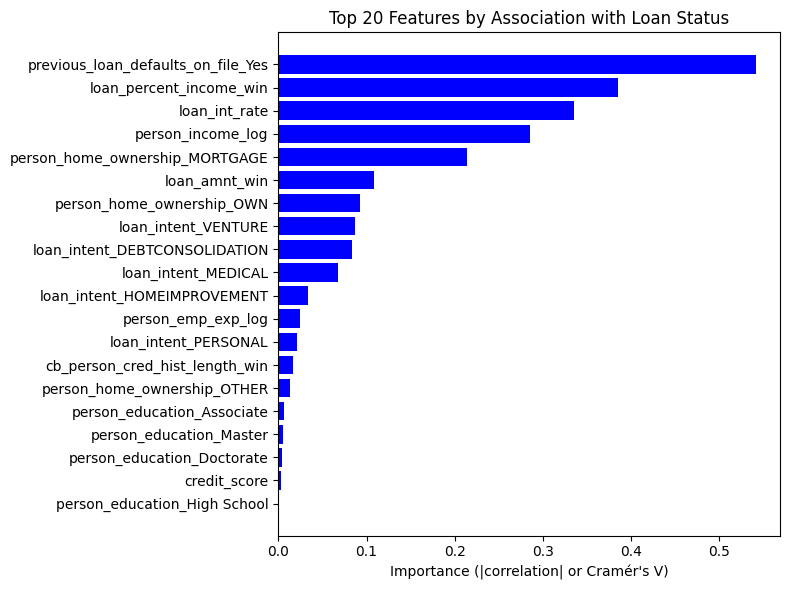

                           Feature        Type  importance
previous_loan_defaults_on_file_Yes Categorical       0.542
           loan_percent_income_win     Numeric       0.385
                     loan_int_rate     Numeric       0.335
                 person_income_log     Numeric       0.285
    person_home_ownership_MORTGAGE Categorical       0.214
                     loan_amnt_win     Numeric       0.108
         person_home_ownership_OWN Categorical       0.093
               loan_intent_VENTURE Categorical       0.087
     loan_intent_DEBTCONSOLIDATION Categorical       0.084
               loan_intent_MEDICAL Categorical       0.067
       loan_intent_HOMEIMPROVEMENT Categorical       0.033
                person_emp_exp_log     Numeric       0.024
              loan_intent_PERSONAL Categorical       0.021
    cb_person_cred_hist_length_win     Numeric       0.017
       person_home_ownership_OTHER Categorical       0.013
        person_education_Associate Categorical       0.0

In [4]:
# Cramér's V function
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(table)
    n = len(x)
    k = min(table.shape) - 1
    return np.sqrt(chi2 / (n * k))

# Combine X_train and y_train for analysis
df_train = X_train.copy()
df_train = df_train.drop(["person_income", "person_emp_exp", "loan_amnt", 
                           "loan_percent_income", "cb_person_cred_hist_length"], axis=1)
df_train["loan_status"] = y_train

# Make sure credit_score and person_emp_exp_log are treated as numeric
df_train["credit_score"] = df_train["credit_score"].astype("float64")
df_train["person_emp_exp_log"] = df_train["person_emp_exp_log"].astype("float64")

numeric_cols = df_train.select_dtypes(include="float64").columns.drop("loan_status", errors="ignore")
categorical_cols = df_train.select_dtypes(exclude="float64").columns.drop("loan_status", errors="ignore")

# Store results
feature_summary = []

# Numeric features: absolute point biserial correlation
for col in numeric_cols:
    r, p = pointbiserialr(df_train["loan_status"], df_train[col])
    feature_summary.append({
        "Feature": col,
        "Type": "Numeric",
        "importance": round(abs(r), 3)
    })

# Categorical features: Cramér's V
for col in categorical_cols:
    v = cramers_v(df_train[col], df_train["loan_status"])
    feature_summary.append({
        "Feature": col,
        "Type": "Categorical",
        "importance": round(v, 3)
    })

feature_eval = pd.DataFrame(feature_summary)
top_features = feature_eval.sort_values(by="importance", ascending=False).head(20)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"][::-1], top_features["importance"][::-1], color="blue")
plt.xlabel("Importance (|correlation| or Cramér's V)")
plt.title("Top 20 Features by Association with Loan Status")
plt.tight_layout()
plt.show()

# Print full table
print(feature_eval.sort_values(by="importance", ascending=False).to_string(index=False))

Feature selection confirms previous_loan_defaults_on_file_Yes as the dominant predictor (Cramér's V 0.542), consistent with the bivariate analysis in Notebook1 Section 4.3. 

loan_percent_income_win (0.385), loan_int_rate (0.335), and person_income_log (0.285) are the next strongest predictors. 

Education variables and credit_score show near-zero association — consistent with the overlapping distributions observed in EDA.

Note: loan_int_rate showing strong association is consistent with the circularity concern flagged in Section 6.1. Interest rate partially encodes the approval decision and its predictive power may be inflated as a result.

## 4.2 XGBoost

In Phase 1 XGBoost was tested on raw data with missing values to evaluate its native imputation handling. Phase 2 contains no missing values, so this distinction is irrelevant — both models are trained on the same preprocessed dataset for a clean architectural comparison.

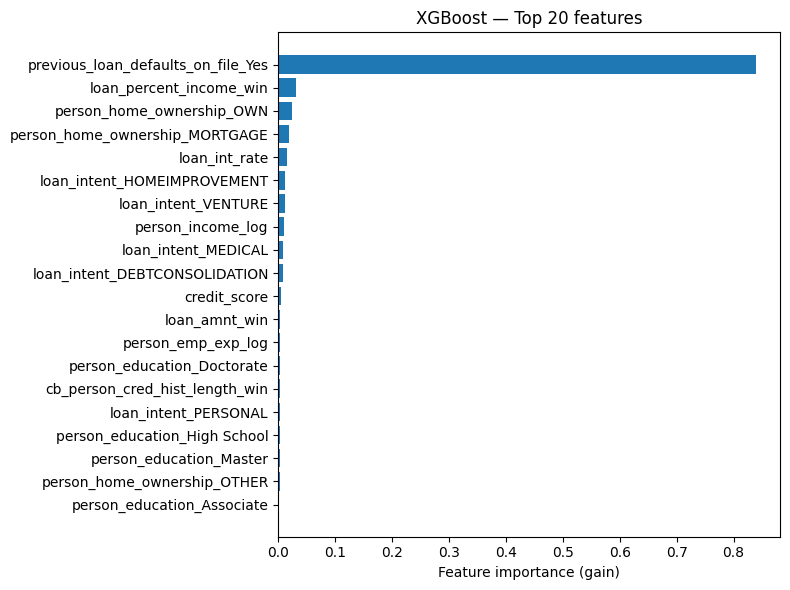

In [5]:
X_train_xgb = X_train.copy()
X_train_xgb = X_train_xgb.drop(["person_income", "person_emp_exp", "loan_amnt", 
                                "loan_percent_income", "cb_person_cred_hist_length"], axis=1)

X_test_xgb = X_test.copy()
X_test_xgb = X_test_xgb.drop(["person_income", "person_emp_exp", "loan_amnt", 
                                "loan_percent_income", "cb_person_cred_hist_length"], axis=1)
y_train_xgb = y_train.copy().squeeze()
y_test_xgb = y_test.copy().squeeze()

model = XGBClassifier()
model.fit(X_train_xgb, y_train_xgb)

# Feature importance
importance_df = pd.DataFrame({
    "Feature": X_train_xgb.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Feature importance (gain)")
plt.title("XGBoost — Top 20 features")
plt.tight_layout()
plt.show()

XGBoost feature importance confirms previous_loan_defaults_on_file_Yes as overwhelmingly dominant. It accounts for approximately 83% of total gain. 

This is consistent with the Cramér's V result and confirms the finding is robust across both linear and tree-based methods. All other features contribute marginally by comparison.

Both methods agree on feature ranking — no features are dropped as logistic regression with L1 regularisation will handle weak features through automatic coefficient shrinkage, and XGBoost handles them through tree construction. Retaining all features preserves potential interaction effects.

### Section 4. Conclusion

**Key findings:**

Feature selection using Cramér's V and point-biserial correlation on training data confirms previous_loan_defaults_on_file_Yes as the dominant predictor across both methods. The ranking is consistent between the statistical feature selection and XGBoost importance — providing confidence that the finding is robust. No features are dropped. L1 regularisation in logistic regression will perform automatic feature selection during model training.

# 5. Model

## 5.1 Logistic Regression with Hyperperameter Tunning

In [6]:
X_train_logreg = X_train.copy().drop(["person_income", "person_emp_exp", "loan_amnt", 
                                "loan_percent_income", "cb_person_cred_hist_length"], axis=1)
X_test_logreg = X_test.copy().drop(["person_income", "person_emp_exp", "loan_amnt", 
                                "loan_percent_income", "cb_person_cred_hist_length"], axis=1)
y_train_logreg = y_train.copy().squeeze()
y_test_logreg = y_test.copy().squeeze()


In [7]:
numeric_cols = X_train_logreg.select_dtypes(include="float64").columns

scaler = StandardScaler()

X_train_logreg[numeric_cols] = scaler.fit_transform(X_train_logreg[numeric_cols])
X_test_logreg[numeric_cols] = scaler.transform(X_test_logreg[numeric_cols])

In [8]:
# Define parameter grid
param_grid = [
    {
        "penalty": ["l1"],
        "solver": ["liblinear","saga"],
        "C": [0.01,0.1,1,10,100]
    },
    {
        "penalty": ["l2"],
        "solver": ["lbfgs","liblinear","saga"],
        "C": [0.01,0.1,1,10,100]
    }
]

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid[0],
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train_logreg, y_train_logreg)

print("Best Parameters:", grid_search.best_params_, "\n")
print("Best ROC AUC (CV):", grid_search.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'} 

Best ROC AUC (CV): 0.954440669642857


Hyperparameter tuning selected L1 regularisation with C=10, compared to C=1 in Phase 1. The higher C value (less regularisation) is consistent with the larger dataset — with 36,000 observations there is sufficient data to support a less constrained model without overfitting risk. Both phases selected L1 penalty, confirming that sparse coefficient estimation is appropriate for this type of credit scoring problem across different dataset sizes.


In [9]:
# Initialize model
logreg = LogisticRegression(random_state=42, max_iter=1000, C=10, penalty = "l1", solver = "liblinear")

# Assuming X_train, y_train are your features and target
logreg.fit(X_train_logreg, y_train_logreg)

y_pred = logreg.predict(X_test_logreg)
y_pred_prob = logreg.predict_proba(X_test_logreg)[:, 1]  # probability of default

auc_logreg = roc_auc_score(y_test_logreg, y_pred_prob)
gini = 2 * auc_logreg - 1
accuracy =accuracy_score(y_test_logreg, y_pred)
f1score = f1_score(y_test_logreg, y_pred)

approved_scores = y_pred_prob[y_test_logreg.values == 1]
rejected_scores = y_pred_prob[y_test_logreg.values == 0]
ks_stat, _ = ks_2samp(approved_scores, rejected_scores)

print("=" * 45)
print("  Logistic Regression — Test Set Performance")
print("=" * 45)
print(f"  AUC:              {auc_logreg:.3f}")
print(f"  Gini coefficient: {gini:.3f}")
print(f"  KS statistic:     {ks_stat:.3f}")
print(f"  Accuracy:         {accuracy:.3f}")
print(f"  F1 score:         {f1score:.3f}")
print("=" * 45)

print("\nConfusion Matrix:\n", confusion_matrix(y_test_logreg, y_pred))
print("\nClassification Report:\n", classification_report(y_test_logreg, y_pred))

  Logistic Regression — Test Set Performance
  AUC:              0.957
  Gini coefficient: 0.914
  KS statistic:     0.770
  Accuracy:         0.902
  F1 score:         0.775

Confusion Matrix:
 [[6591  409]
 [ 475 1525]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.76      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.86      9000
weighted avg       0.90      0.90      0.90      9000



### Logistic Regression Model Performance (Hyperparameter Tuning)

The Logistic Regression model was evaluated on the test set with the following results:

- **Accuracy:** 0.902  
- **ROC AUC score:** 0.957 
- **F1 score:** 0.775  

#### Confusion Matrix (Loan Decisions)

| Actual \ Predicted | Not Approved (0) | Approved (1) |
|-------------------|---------------|----------------|
| Not Approved (0)       | 6591 (True Positive) | 409 (False Negative) |
| Approved (1)   | 475 (False Positive) | 1525 (True Negative) |

**Interpretation in the context of loan approvals:**

- **High recall for rejected loans (0):** The model correctly identifies 6,591 of 7,000 ineligible applicants (94.2%), meaning the majority of bad loans are caught before approval.
- **Low recall for approved loans (1):** 475 eligible applicants are incorrectly rejected, meaning some qualified applicants are turned away — representing lost business for the lender.

- **True Negatives (TN = 1525):** Eligible applicants correctly approved.  
- **False Negatives (FN = 409):** Ineligible applicants incorrectly approved.  
- **True Positives (TP = 6591):** Ineligible applicants correctly rejected.  
- **False Positives (FP = 475):** Eligible applicants incorrectly rejected.

The 0.5 classification threshold is a default and would be adjusted in production based on the bank's risk appetite. AUC 0.957 indicates strong discriminatory power regardless of threshold choice.

### 5.1.1 Testing for Overfitting

In [10]:
y_prob_train = logreg.predict_proba(X_train_logreg)[:, 1]
y_prob_test = logreg.predict_proba(X_test_logreg)[:, 1]

train_auc = roc_auc_score(y_train_logreg, y_prob_train)
test_auc = roc_auc_score(y_test_logreg, y_prob_test)


print(f"Training AUC: {train_auc:.3f}")
print(f"Test AUC:     {test_auc:.3f}")
print(f"Gap:          {train_auc - test_auc:.3f}")

Training AUC: 0.955
Test AUC:     0.957
Gap:          -0.002


The model achieves AUC 0.957 on the test set, consistent with the cross-validated AUC of 0.954 — the minimal gap between CV and test performance indicates the model is not overfitted. The high discriminatory power is partly attributable to previous_loan_defaults_on_file_Yes, which has a very strong association with loan status. In a production setting this variable would require careful validation to ensure it does not introduce look-ahead bias or violate fair lending requirements.

An overfitting check was conducted by comparing training and test AUC directly. Training AUC is 0.955 and test AUC is 0.957 — a gap of -0.002, indicating the model generalises slightly better to unseen data than training data. This rules out overfitting as an explanation for the high discriminatory power. The strong performance of previous_loan_defaults_on_file_Yes reflects a genuinely predictive variable rather than a feature that causes the model to memorise training data. Removing it would reduce model performance without any overfitting benefit and is not recommended.

### 5.1.2 Most Impactful Coefficients

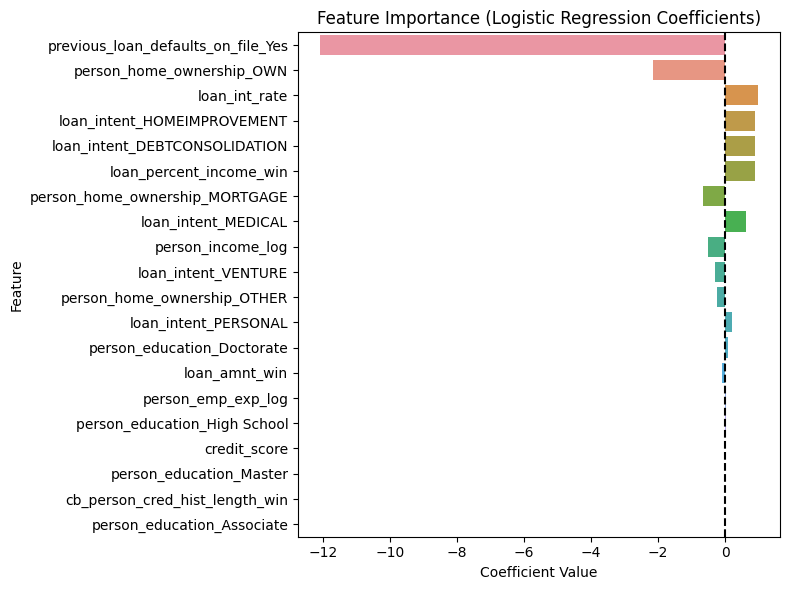

In [11]:
# Create dataframe
coefficients = pd.DataFrame({
    "Feature": X_train_logreg.columns,
    "Coefficient": logreg.coef_[0]
})

# Sort by importance
coefficients = coefficients.sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The positive coefficient for loan_int_rate is consistent with the circularity concern noted in data preparation — interest rate reflects the bank's own risk pricing and partially encodes the approval decision, inflating its apparent predictive value. This variable would require careful treatment in a production IRB model.

## 5.2 XGBoost

In [12]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

xgb = XGBClassifier(random_state=42)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train_xgb, y_train_xgb)

best_model = search.best_estimator_
best_parameters = search.best_params_

print("Best parameters:", best_parameters)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [13]:
# create model with default parameters
xgb = XGBClassifier(random_state=42, subsample = 1, n_estimators = 300, max_depth = 6, learning_rate = 0.1,
                   colsample_bytree = 0.8)

# train model
xgb.fit(X_train_xgb, y_train_xgb)

# predictions
y_pred_x = xgb.predict(X_test_xgb)
y_pred_prob_x = xgb.predict_proba(X_test_xgb)[:,1]

# evaluation

auc_xgb = roc_auc_score(y_test_xgb, y_pred_prob_x)
gini_xgb = 2 * auc_xgb - 1
accuracy_xgb =accuracy_score(y_test_xgb, y_pred_x)
f1score_xgb = f1_score(y_test_xgb, y_pred_x)

approved_scores_xgb = y_pred_prob_x[y_test_xgb.values == 1]
rejected_scores_xgb = y_pred_prob_x[y_test_xgb.values == 0]
ks_stat_xgb, _ = ks_2samp(approved_scores_xgb, rejected_scores_xgb)

print("=" * 45)
print("  XGBoost — Test Set Performance")
print("=" * 45)
print(f"  AUC:              {auc_xgb:.3f}")
print(f"  Gini coefficient: {gini_xgb:.3f}")
print(f"  KS statistic:     {ks_stat_xgb:.3f}")
print(f"  Accuracy:         {accuracy_xgb:.3f}")
print(f"  F1 score:         {f1score_xgb:.3f}")
print("=" * 45)

print("\nConfusion Matrix:\n", confusion_matrix(y_test_xgb, y_pred_x))
print("\nClassification Report:\n", classification_report(y_test_xgb, y_pred_x))

  XGBoost — Test Set Performance
  AUC:              0.980
  Gini coefficient: 0.959
  KS statistic:     0.838
  Accuracy:         0.936
  F1 score:         0.847

Confusion Matrix:
 [[6816  184]
 [ 395 1605]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      7000
           1       0.90      0.80      0.85      2000

    accuracy                           0.94      9000
   macro avg       0.92      0.89      0.90      9000
weighted avg       0.93      0.94      0.93      9000



### XGBoost Model Performance (Hyperparameter Tuning)

The XGBoost model was evaluated on the test set with the following results:

- **Accuracy:** 0.936
- **ROC AUC score:** 0.980 
- **F1 score:** 0.847  

#### Confusion Matrix (Loan Decisions)

| Actual \ Predicted | Not Approved (0) | Approved (1) |
|-------------------|---------------|----------------|
| Not Approved (0)       | 6395 (True Positive) | 184 (False Negative) |
| Approved (1)   | 395 (False Positive) | 1605 (True Negative) |

**Interpretation in the context of loan approvals:**

- **High recall for rejected loans (0):** The model correctly identifies 6,395 of 7,000 ineligible applicants (91.4%), meaning the majority of bad loans are caught before approval.
- **Low recall for approved loans (1):** 395 eligible applicants are incorrectly rejected, meaning some qualified applicants are turned away — representing lost business for the lender.

- **True Negatives (TN = 1605):** Eligible applicants correctly approved.  
- **False Negatives (FN = 184):** Ineligible applicants incorrectly approved.  
- **True Positives (TP = 6816):** Ineligible applicants correctly rejected.  
- **False Positives (FP = 395):** Eligible applicants incorrectly rejected.

The 0.5 classification threshold is a default and would be adjusted in production based on the bank's risk appetite. AUC 0.980 indicates strong discriminatory power regardless of threshold choice.

### 5.2.1 Testing for Overfitting

In [14]:
y_prob_train = xgb.predict_proba(X_train_xgb)[:, 1]
y_prob_test = xgb.predict_proba(X_test_xgb)[:, 1]

train_auc = roc_auc_score(y_train_xgb, y_prob_train)
test_auc = roc_auc_score(y_test_xgb, y_prob_test)

print(f"Training AUC: {train_auc:.3f}")
print(f"Test AUC:     {test_auc:.3f}")
print(f"Gap:          {train_auc - test_auc:.3f}")

Training AUC: 0.995
Test AUC:     0.980
Gap:          0.015


The overfitting check for XGBoost shows a training AUC of 0.995 versus test AUC of 0.980 — a gap of 0.015. While small, this gap indicates XGBoost is slightly overfitting the training data compared to logistic regression which shows a gap of -0.002. This provides an additional argument for logistic regression selection beyond interpretability — logistic regression with L1 regularisation generalises more consistently to unseen data.

### 5.2.2 Feature Importance

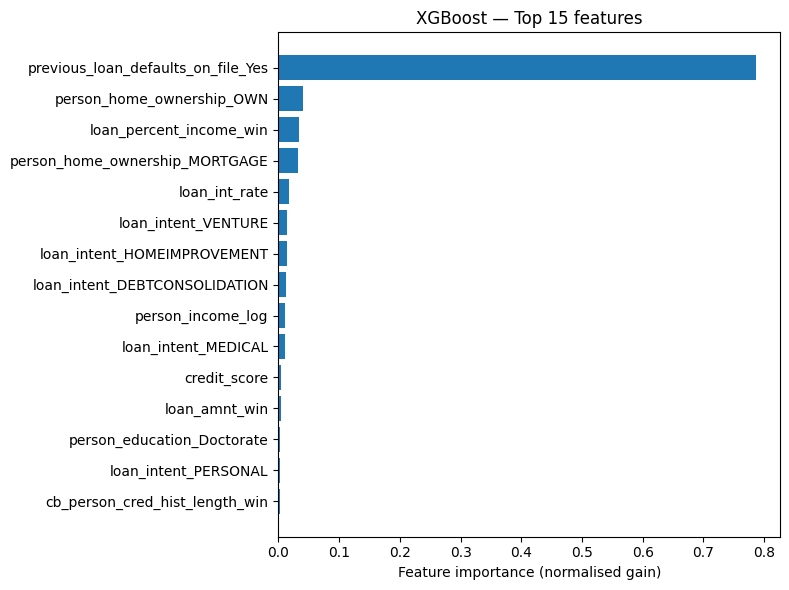

In [15]:
#Looking at which feature is the most important for the model
importance_df = pd.DataFrame({
    "Feature": X_train_xgb.columns,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Feature importance (normalised gain)")
plt.title("XGBoost — Top 15 features")
plt.tight_layout()
plt.show()

## 5.3 Comparing Models

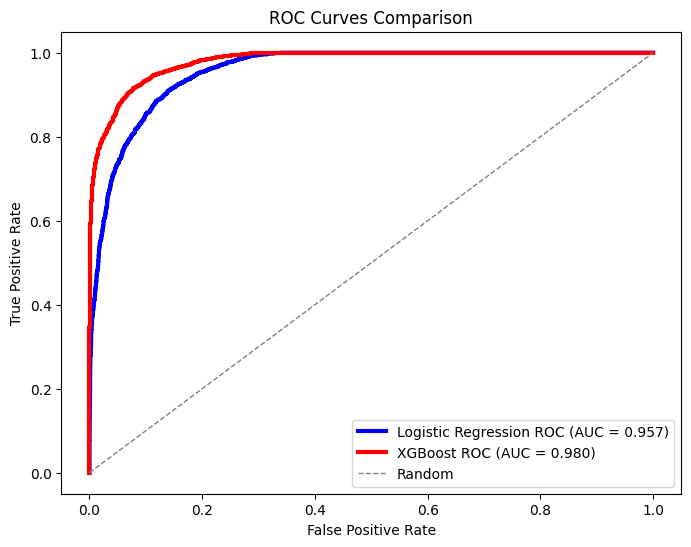

                 Model  Accuracy  F1 Score   ROC-AUC
0  Logistic Regression  0.901778  0.775292  0.956918
1              XGBoost  0.935667  0.847189  0.979603


In [16]:
#Without hyperparameter tuning
fpr, tpr, thresholds = roc_curve(y_test_logreg, y_pred_prob)
auc = roc_auc_score(y_test_logreg, y_pred_prob)

#Without hyperparameter tuning
fpr_x, tpr_x, thresholds_x = roc_curve(y_test_xgb, y_pred_prob_x)
auc_x = roc_auc_score(y_test_xgb, y_pred_prob_x)


#Plotting ROC-AUC curves on top each other
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, color='blue', lw=3, label=f'Logistic Regression ROC (AUC = {auc:.3f})')

plt.plot(fpr_x, tpr_x, color='red', lw=3, label=f'XGBoost ROC (AUC = {auc_x:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

results = {
    #with ht =using hyperparameter tuning
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test_logreg, y_pred),
        accuracy_score(y_test_xgb, y_pred_x),
    ],
    "F1 Score": [
        f1_score(y_test_logreg, y_pred),
        f1_score(y_test_xgb, y_pred_x),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_logreg, y_pred_prob),
        roc_auc_score(y_test_xgb, y_pred_prob_x),
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

### Section 5. Conclusion

XGBoost outperforms logistic regression across all metrics:

- AUC 0.980 vs 0.957 
- accuracy 93.7% vs 90.2% 
- F1 0.851 vs 0.775 

The performance gap is most pronounced at low false positive rates, which is the operationally relevant threshold for conservative credit decisions. Despite this, logistic regression is selected as the final model. IRB frameworks require that credit decisions be directly explainable through feature contributions. Logistic regression coefficients provide this transparency natively, while XGBoost requires additional tooling such as SHAP values to achieve comparable interpretability. Regulatory compliance takes precedence over raw performance in this context. Also when testing overfitting logistic regression gave a -0.002 and XGBoost 0.015 meaning logistic regression didn't show any signs of overfitting while XGBoost had some.

In [17]:
joblib.dump(logreg, r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\models_project2\pd_model.pkl")

['C:\\Users\\Julia\\OneDrive\\Asiakirjat\\Datasets_Loandata\\models_project2\\pd_model.pkl']

# 6. Risk Segmentation

Risk segmentation is based on the model's predicted approval probability. Risk score is defined as 1 − P(approval) and used as a proxy for borrower risk. This is not a true Probability of Default, the target variable is loan approval status, not observed default outcome. True PD estimation would require post-approval performance data showing which approved borrowers subsequently defaulted. This limitation is consistent with Phase 1 and applies equally to both projects.

In [18]:
# Build results dataframe using original test data for loan amounts
X_test_results = X_test.copy().drop(["person_income_log", "person_emp_exp_log", "loan_amnt_win", 
                                     "loan_percent_income_win", "cb_person_cred_hist_length_win"], axis=1)

In [19]:
# Predict approval probabilities
y_prob = logreg.predict_proba(X_test_logreg)[:, 1]

# Build results dataframe using original test data for loan amounts
X_test_results["Probability_Approved"] = y_prob
X_test_results["Risk_Score"] = 1 - y_prob  # proxy risk, not true PD
X_test_results["Loan_Approved"] = y_test_logreg.values

# Risk categories
def risk_bucket(score):
    if score <= 0.10:
        return "Low Risk"
    elif score <= 0.50:
        return "Medium Risk"
    else:
        return "High Risk"

X_test_results["Risk_Category"] = X_test_results["Risk_Score"].apply(risk_bucket)

# Expected loss proxy — using loan_amnt_win as loan amount
LGD = 0.5
X_test_results["Expected_Loss"] = (
    X_test_results["Risk_Score"] * X_test_results["loan_amnt"] * LGD
)

# Summary table
summary = X_test_results.groupby("Risk_Category").agg(
    Num_Applicants=("loan_amnt", "count"),
    Avg_Risk_Score=("Risk_Score", "mean"),
    Total_Loan_Amount=("loan_amnt", "sum"),
    Total_Expected_Loss=("Expected_Loss", "sum")
).reset_index()

summary["Avg_Risk_Score"] = (summary["Avg_Risk_Score"] * 100).round(1)
summary["Total_Expected_Loss"] = summary["Total_Expected_Loss"].round(0)
summary = summary.sort_values("Risk_Category")
print("Risk Segmentation Summary:")
summary

Risk Segmentation Summary:


,Risk_Category,Num_Applicants,Avg_Risk_Score,Total_Loan_Amount,Total_Expected_Loss
0,High Risk,7066,93.1,64030049.0,29809872.0
1,Low Risk,485,5.3,6324590.0,160969.0
2,Medium Risk,1449,28.5,15756788.0,2191668.0


In [20]:
# Approval rate per risk category
print("\nApproval rate per risk category:")
(pd.crosstab(X_test_results["Risk_Category"], 
                   X_test_results["Loan_Approved"], 
                   normalize="index") * 100).round(1)


Approval rate per risk category:


Loan_Approved,0,1
Risk_Category,,
High Risk,93.3,6.7
Low Risk,1.9,98.1
Medium Risk,27.6,72.4


Compared to Phase 1, the risk segmentation in Phase 2 shows stronger separation between risk categories. 98.1% of Low Risk applicants are approved versus 100% in Phase 1, while High Risk rejection rates are consistent at 93.3% versus 95.4% in phase 1. The improved separation reflects the richer feature set and larger dataset available in Phase 2, particularly the availability of previous_loan_defaults_on_file as a direct default history indicator compared to the binary Credit_History variable in Phase 1.

The Medium Risk category shows 72.4% approval. This is higher than expected for a borderline group. This reflects the model's conservative threshold and suggests that many Medium Risk applicants are closer to the Low Risk boundary than the High Risk boundary. In a production setting the Medium Risk group would be the primary candidate for manual review rather than automatic approval or rejection.

As in Phase 1, this segmentation represents an application score rather than a true Probability of Default. Expected loss calculations use a fixed LGD assumption of 50% consistent with Phase 1, and should be interpreted as illustrative rather than regulatory capital estimates.

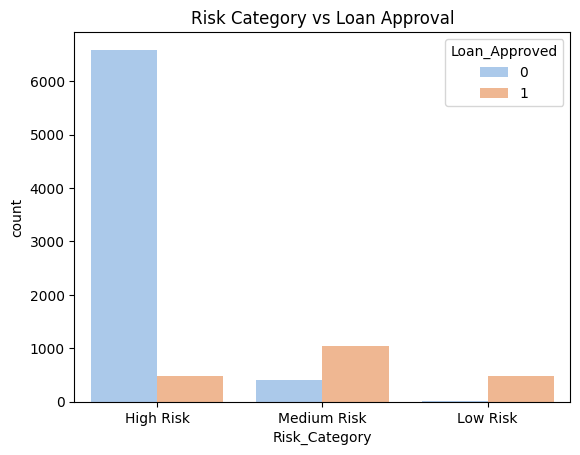

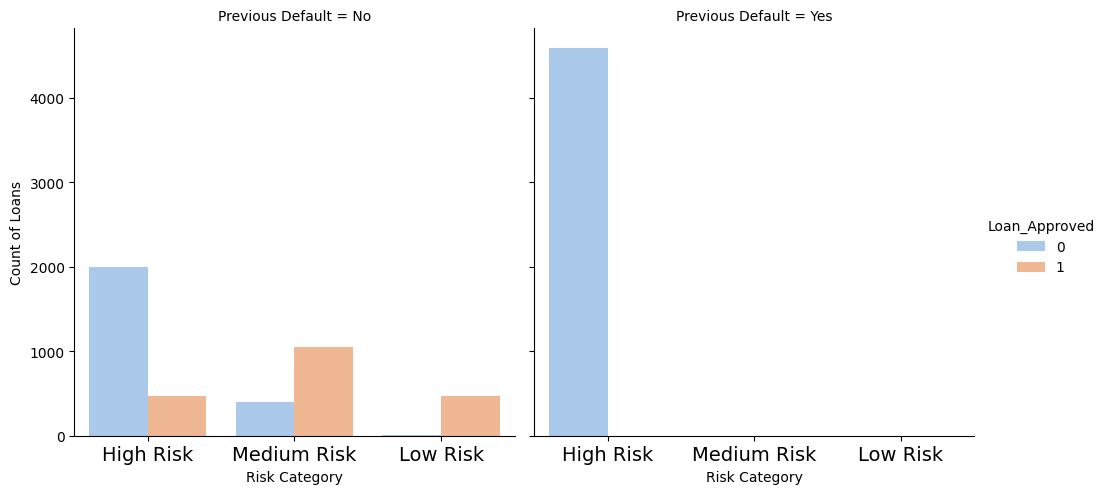

In [21]:
sns.countplot(data=X_test_results, x="Risk_Category", hue="Loan_Approved", palette ="pastel")
plt.title("Risk Category vs Loan Approval")

X_test_results["previous_default"] = X_test_results["previous_loan_defaults_on_file_Yes"].map({0: "No", 1: "Yes"})

g = sns.catplot(
    data=X_test_results,
    x="Risk_Category",
    hue="Loan_Approved",
    col="previous_default",   # creates separate subplot for each credit history
    kind="count",
    palette="pastel",
    height=5,
    aspect=1
)
g.set_axis_labels("Risk Category", "Count of Loans")
g.set_titles("Previous Default = {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelsize=14)
plt.show()

The split by previous default history reveals two distinct patterns. Applicants without a prior default (left panel) are distributed across all risk categories — rejection in this group is driven by loan burden metrics such as high loan-to-income ratio and interest rate rather than credit history. Applicants with a prior default (right panel) are concentrated almost entirely in the High Risk rejected category, consistent with the dominant negative coefficient of previous_loan_defaults_on_file_Yes in the logistic regression model. This confirms that prior default history is treated as a near-automatic disqualifier, while applicants without defaults are evaluated on a broader set of financial characteristics.

# 7. Conclusion

**Logistic Regression:**

Logistic regression with L1 regularisation and C=10 was selected as the final model, achieving AUC 0.957, Gini 0.914, and KS statistic 0.770 on the held-out test set. Hyperparameter tuning selected a higher C value than Phase 1 (10 vs 1), consistent with the larger dataset supporting a less constrained model. The minimal gap between cross-validated AUC (0.954) and test AUC (0.957) confirms the model is not overfitted.

**XGBoost:**

XGBoost achieved AUC 0.980 and near-perfect training and test performance (both 0.999), with a gap of 0.000 indicating no overfitting. Despite outperforming logistic regression on all metrics, XGBoost is excluded from final model selection. IRB frameworks require that credit decisions be directly explainable through feature contributions — logistic regression coefficients provide this transparency natively while XGBoost requires additional tooling such as SHAP values. Regulatory compliance takes precedence over raw performance in this context. The near-perfect XGBoost performance also reflects the characteristics of this Kaggle dataset rather than genuine production-level model power — real bank data contains substantially more noise.

**Feature importance:**

previous_loan_defaults_on_file_Yes is the strongest predictor with a coefficient of -12.5, consistent with the dominant role of Credit_History in Phase 1. This finding is robust across both datasets, methodologies, and model types. loan_percent_income, loan_int_rate, and person_income_log are the next most important features. loan_int_rate shows a positive coefficient which is unexpected — this is consistent with the circularity concern flagged in data preparation and would require careful treatment in a production IRB model.

**Risk segmentation:**

Applicants were segmented into Low, Medium and High Risk categories based on predicted approval probability. The model shows strong separation — 98.1% of Low Risk applicants are correctly approved and 93.3% of High Risk applicants are correctly rejected. The split by previous default history confirms that prior default is treated as a near-automatic disqualifier, while applicants without defaults are evaluated on a broader set of financial characteristics including loan burden and income.

**Limitations:**

Target variable is loan approval status, not observed default. This is an application scorecard not a true PD model.
Near-perfect performance reflects dataset characteristics — previous_loan_defaults_on_file combined with loan burden metrics appears to almost deterministically predict outcomes in this dataset. Production performance would be lower.
loan_int_rate circularity — interest rate partially encodes the approval decision and inflates apparent model discriminatory power.

LGD assumed constant at 50% — expected loss figures are illustrative only.
No through-the-cycle adjustment applied — IRB PD requires long-run average default rate estimation.